# Business EDA — hiểu dataset bán lẻ và thiết kế dữ liệu 3NF

Notebook này trả lời bốn câu hỏi theo đúng thứ tự cần dùng khi bảo vệ:

1. **Dataset đang kể câu chuyện vận hành nào?**
2. **Các chỉ số và thuật ngữ business được tính ra sao?**
3. **EDA quan sát được điều gì có giá trị cho quyết định kinh doanh?**
4. **Vì sao mô hình quan hệ được thiết kế như vậy, và điều gì giúp nó đạt 3NF?**

Quy ước trung thực trong toàn notebook:

- **Quan sát**: kết quả đếm/tính trực tiếp từ 14 CSV.
- **Tái dựng quyết định**: nguồn thiếu khóa dòng hàng nên phải gán `line_number` theo thứ tự nguồn.
- **Diễn giải/giả thuyết business**: cách giải thích hợp lý, nhưng dữ liệu chưa đủ để chứng minh quan hệ nhân quả.

Notebook không kết nối database và không xây forecasting model. `sample_submission.csv` chỉ là output dự báo mẫu, **không phải actual**.

Notebook này là phần bằng chứng chạy lại được cho `docs/data_business_analysis_workflow.md`. Ánh xạ chính: business và grain ở §1–2; data inventory và chất lượng ở §1.1; KPI ở §3–5; EDA theo câu hỏi ở §5–10; phân biệt bằng chứng với giả thuyết xuyên suốt notebook; deliverables và giới hạn ở §11–13.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

DATA = 'data'
R = lambda f, **k: pd.read_csv(f'{DATA}/{f}', low_memory=False, **k)

def show(df, formats=None):
    # Display gọn mà không phụ thuộc pandas Styler/jinja2.
    out = df.copy()
    for column, fmt in (formats or {}).items():
        if column in out:
            out[column] = out[column].map(lambda value: fmt.format(value) if pd.notna(value) else '')
    display(out)

files = [
    'customers.csv', 'geography.csv', 'products.csv', 'promotions.csv',
    'orders.csv', 'order_items.csv', 'payments.csv', 'shipments.csv',
    'returns.csv', 'reviews.csv', 'inventory.csv', 'web_traffic.csv',
    'sales.csv', 'sample_submission.csv'
]
data = {f.removesuffix('.csv'): R(f) for f in files}

for table, date_columns in {
    'customers': ['signup_date'], 'promotions': ['start_date', 'end_date'],
    'orders': ['order_date'], 'shipments': ['ship_date', 'delivery_date'],
    'returns': ['return_date'], 'reviews': ['review_date'],
    'inventory': ['snapshot_date'], 'web_traffic': ['date'],
    'sales': ['Date'], 'sample_submission': ['Date']
}.items():
    for column in date_columns:
        data[table][column] = pd.to_datetime(data[table][column])

print(f'Đã đọc {len(data)}/14 nguồn, tổng {sum(len(df) for df in data.values()):,} dòng.')

Đã đọc 14/14 nguồn, tổng 2,960,736 dòng.


## 1. Dataset nói về business gì?

Đây là dữ liệu của một doanh nghiệp bán lẻ thời trang, bao phủ toàn bộ vòng đời:

> **Khách ở một nơi → đặt đơn → đơn có các dòng sản phẩm → promotion giảm giá dòng hàng → đơn được thanh toán và giao → dòng hàng có thể bị trả hoặc được đánh giá.**

Ngoài xương sống giao dịch còn có tồn kho theo tháng, traffic website theo ngày, báo cáo sales lịch sử và khung dự báo tương lai.

### Thuật ngữ nền tảng: grain

**Grain** là “một dòng đại diện cho cái gì”. Đây là câu hỏi phải trả lời trước mọi phép join hay KPI. Ví dụ:

- grain của `orders` là **một đơn**;
- grain của `order_items` là **một dòng sản phẩm trong đơn**;
- grain của `inventory` là **một sản phẩm tại một snapshot cuối tháng**;
- grain của `sales` là **một ngày**.

Join hai bảng mà không hiểu grain dễ làm một dòng nở thành nhiều dòng (**fan-out**) và cộng doanh thu sai.

In [2]:
grain = {
    'customers': ('một khách hàng', 'customer_id', 'Ai mua?'),
    'geography': ('một mã zip', 'zip', 'Khách ở đâu?'),
    'products': ('một SKU/biến thể', 'product_id', 'Bán sản phẩm gì?'),
    'promotions': ('một chương trình khuyến mãi', 'promo_id', 'Giảm giá theo quy tắc nào?'),
    'orders': ('một đơn hàng', 'order_id', 'Giao dịch nào phát sinh?'),
    'order_items': ('một dòng sản phẩm trong đơn', 'chưa có khóa hợp lệ từ nguồn', 'Đơn mua sản phẩm gì?'),
    'payments': ('thanh toán của một đơn', 'order_id', 'Khách trả bao nhiêu/kỳ?'),
    'shipments': ('vận chuyển của một đơn', 'order_id', 'Giao hàng thế nào?'),
    'returns': ('một lần trả dòng hàng', 'return_id', 'Sản phẩm nào bị trả?'),
    'reviews': ('một đánh giá dòng hàng', 'review_id', 'Khách phản hồi gì?'),
    'inventory': ('một sản phẩm tại một snapshot tháng', '(snapshot_date, product_id)', 'Tồn kho vận hành ra sao?'),
    'web_traffic': ('traffic tổng hợp của một ngày', 'date', 'Website được truy cập thế nào?'),
    'sales': ('sales actual của một ngày', 'Date', 'Revenue/COGS lịch sử là bao nhiêu?'),
    'sample_submission': ('một ngày tương lai cần dự báo', 'Date', 'Định dạng output, không phải actual')
}

date_scope = {
    'customers': ['signup_date'], 'promotions': ['start_date', 'end_date'],
    'orders': ['order_date'], 'shipments': ['ship_date', 'delivery_date'],
    'returns': ['return_date'], 'reviews': ['review_date'],
    'inventory': ['snapshot_date'], 'web_traffic': ['date'],
    'sales': ['Date'], 'sample_submission': ['Date']
}

def get_time_scope(name):
    columns = date_scope.get(name, [])
    if not columns:
        return 'Không có cột ngày'
    values = pd.concat([data[name][column].dropna() for column in columns], ignore_index=True)
    return f'{values.min().date()} → {values.max().date()}'

overview = pd.DataFrame([
    {'file': f'{name}.csv', 'rows': len(data[name]), 'columns': data[name].shape[1],
     'time_scope': get_time_scope(name), 'grain': grain[name][0],
     'source_key': grain[name][1], 'business_question': grain[name][2]}
    for name in data
])
show(overview, {'rows': '{:,.0f}', 'columns': '{:,.0f}'})

,file,rows,columns,time_scope,grain,source_key,business_question
0,customers.csv,"121,930",7,2012-01-17 → 2022-12-31,một khách hàng,customer_id,Ai mua?
1,geography.csv,"39,948",4,Không có cột ngày,một mã zip,zip,Khách ở đâu?
2,products.csv,"2,412",8,Không có cột ngày,một SKU/biến thể,product_id,Bán sản phẩm gì?
3,promotions.csv,50,10,2013-01-31 → 2022-12-31,một chương trình khuyến mãi,promo_id,Giảm giá theo quy tắc nào?
4,orders.csv,"646,945",8,2012-07-04 → 2022-12-31,một đơn hàng,order_id,Giao dịch nào phát sinh?
5,order_items.csv,"714,669",7,Không có cột ngày,một dòng sản phẩm trong đơn,chưa có khóa hợp lệ từ nguồn,Đơn mua sản phẩm gì?
6,payments.csv,"646,945",4,Không có cột ngày,thanh toán của một đơn,order_id,Khách trả bao nhiêu/kỳ?
7,shipments.csv,"566,067",4,2012-07-04 → 2022-12-31,vận chuyển của một đơn,order_id,Giao hàng thế nào?
8,returns.csv,"39,939",7,2012-07-11 → 2022-12-31,một lần trả dòng hàng,return_id,Sản phẩm nào bị trả?
9,reviews.csv,"113,551",7,2012-07-10 → 2022-12-31,một đánh giá dòng hàng,review_id,Khách phản hồi gì?


### 1.1 Chất lượng dữ liệu, khóa và quan hệ

Ba bảng dưới đây tách rõ: (1) mức đầy đủ và tính duy nhất của từng nguồn, (2) orphan trên toàn bộ các quan hệ nguồn, và (3) các luật nghiệp vụ cơ bản. Null không tự động là lỗi: chẳng hạn `promo_id_2` trống nghĩa là dòng hàng không có promotion thứ hai.

In [3]:
source_keys = {
    'customers': ['customer_id'], 'geography': ['zip'], 'products': ['product_id'],
    'promotions': ['promo_id'], 'orders': ['order_id'], 'order_items': None,
    'payments': ['order_id'], 'shipments': ['order_id'], 'returns': ['return_id'],
    'reviews': ['review_id'], 'inventory': ['snapshot_date', 'product_id'],
    'web_traffic': ['date'], 'sales': ['Date'], 'sample_submission': ['Date']
}

quality_rows = []
for name, df in data.items():
    key = source_keys[name]
    quality_rows.append({
        'table': name,
        'rows': len(df),
        'duplicate_full_rows': int(df.duplicated().sum()),
        'null_cells': int(df.isna().sum().sum()),
        'columns_with_null': int(df.isna().any().sum()),
        'null_key_rows': int(df[key].isna().any(axis=1).sum()) if key else np.nan,
        'duplicate_key_rows': int(df.duplicated(key).sum()) if key else np.nan
    })
quality_report = pd.DataFrame(quality_rows)
print('Chất lượng ở grain nguồn; order_items chưa có khóa dòng hàng trong CSV:')
show(quality_report, {column: '{:,.0f}' for column in quality_report.columns if column != 'table'})

relationships = [
    ('customers', 'zip', 'geography', 'zip'),
    ('orders', 'customer_id', 'customers', 'customer_id'),
    ('orders', 'zip', 'geography', 'zip'),
    ('order_items', 'order_id', 'orders', 'order_id'),
    ('order_items', 'product_id', 'products', 'product_id'),
    ('order_items', 'promo_id', 'promotions', 'promo_id'),
    ('order_items', 'promo_id_2', 'promotions', 'promo_id'),
    ('payments', 'order_id', 'orders', 'order_id'),
    ('shipments', 'order_id', 'orders', 'order_id'),
    ('returns', 'order_id', 'orders', 'order_id'),
    ('returns', 'product_id', 'products', 'product_id'),
    ('reviews', 'order_id', 'orders', 'order_id'),
    ('reviews', 'product_id', 'products', 'product_id'),
    ('reviews', 'customer_id', 'customers', 'customer_id'),
    ('inventory', 'product_id', 'products', 'product_id')
]
relationship_report = pd.DataFrame([
    {
        'relationship': f'{child}.{child_key} → {parent}.{parent_key}',
        'non_null_child_rows': int(data[child][child_key].notna().sum()),
        'orphan_rows': int((~data[child][child_key].dropna().isin(data[parent][parent_key])).sum())
    }
    for child, child_key, parent, parent_key in relationships
])
print('Toàn vẹn tham chiếu trên các cột liên kết của nguồn:')
show(relationship_report, {'non_null_child_rows': '{:,.0f}', 'orphan_rows': '{:,.0f}'})

sales_dates = data['sales']['Date']
expected_sales_dates = pd.date_range(sales_dates.min(), sales_dates.max(), freq='D')
rule_report = pd.DataFrame([
    ('sales thiếu ngày trong khoảng lịch sử', len(expected_sales_dates.difference(sales_dates))),
    ('promotion có end_date trước start_date', int((data['promotions'].end_date < data['promotions'].start_date).sum())),
    ('shipment có delivery_date trước ship_date', int((data['shipments'].delivery_date < data['shipments'].ship_date).sum())),
    ('order_item có quantity <= 0', int((data['order_items'].quantity <= 0).sum())),
    ('order_item có unit_price < 0', int((data['order_items'].unit_price < 0).sum())),
    ('payment có payment_value < 0', int((data['payments'].payment_value < 0).sum())),
    ('return có return_quantity <= 0', int((data['returns'].return_quantity <= 0).sum())),
    ('review có rating ngoài [1, 5]', int((~data['reviews'].rating.between(1, 5)).sum())),
    ('inventory có stock_on_hand < 0', int((data['inventory'].stock_on_hand < 0).sum()))
], columns=['rule', 'violating_rows'])
print('Các luật cấu trúc/nghiệp vụ cơ bản:')
show(rule_report, {'violating_rows': '{:,.0f}'})

Chất lượng ở grain nguồn; order_items chưa có khóa dòng hàng trong CSV:


,table,rows,duplicate_full_rows,null_cells,columns_with_null,null_key_rows,duplicate_key_rows
0,customers,"121,930",0,0,0,0,0
1,geography,"39,948",0,0,0,0,0
2,products,"2,412",0,0,0,0,0
3,promotions,50,0,40,1,0,0
4,orders,"646,945",0,0,0,0,0
5,order_items,"714,669",0,"1,152,816",2,,
6,payments,"646,945",0,0,0,0,0
7,shipments,"566,067",0,0,0,0,0
8,returns,"39,939",0,0,0,0,0
9,reviews,"113,551",0,0,0,0,0


Toàn vẹn tham chiếu trên các cột liên kết của nguồn:


,relationship,non_null_child_rows,orphan_rows
0,customers.zip → geography.zip,"121,930",0
1,orders.customer_id → customers.customer_id,"646,945",0
2,orders.zip → geography.zip,"646,945",0
3,order_items.order_id → orders.order_id,"714,669",0
4,order_items.product_id → products.product_id,"714,669",0
5,order_items.promo_id → promotions.promo_id,"276,316",0
6,order_items.promo_id_2 → promotions.promo_id,206,0
7,payments.order_id → orders.order_id,"646,945",0
8,shipments.order_id → orders.order_id,"566,067",0
9,returns.order_id → orders.order_id,"39,939",0


Các luật cấu trúc/nghiệp vụ cơ bản:


,rule,violating_rows
0,sales thiếu ngày trong khoảng lịch sử,0
1,promotion có end_date trước start_date,0
2,shipment có delivery_date trước ship_date,0
3,order_item có quantity <= 0,0
4,order_item có unit_price < 0,0
5,payment có payment_value < 0,0
6,return có return_quantity <= 0,0
7,"review có rating ngoài [1, 5]",0
8,inventory có stock_on_hand < 0,0


### Bốn cụm nghiệp vụ

| Cụm | Luồng | Ý nghĩa |
|---|---|---|
| Khách hàng | `geography → customers` | hồ sơ và nơi cư trú |
| Giao dịch | `customers → orders → order_items ← products` | xương sống tạo doanh thu và giá vốn |
| Hoàn tất/hậu mãi | `orders → payments/shipments`; `order_items → returns/reviews` | thanh toán, giao hàng, trả hàng, hài lòng |
| Vận hành/tổng hợp | `products → inventory`; `web_traffic`; `sales`; `sample_submission` | tồn kho, kênh số, actual theo ngày, output dự báo |

`web_traffic` chỉ có grain ngày, không có `session_id`, `customer_id` hay `order_id`; vì vậy phép ghép traffic với sales theo ngày là **time alignment**, không phải foreign key và cũng không chứng minh conversion.

## 2. Một đơn hàng thật để nhớ toàn bộ luồng

`order_id = 46270` cho thấy cách các bảng phối hợp. Dùng một ví dụ thật giúp phân biệt rõ “đơn hàng” với “dòng hàng”, cũng như Gross Revenue với Net Payment.

In [4]:
customers, geography = data['customers'], data['geography']
products, promotions = data['products'], data['promotions']
orders, items = data['orders'], data['order_items'].copy()
payments, shipments = data['payments'], data['shipments']
returns, reviews = data['returns'], data['reviews']

items['line_number'] = items.groupby('order_id', sort=False).cumcount() + 1

order_id = 46270
story = (orders.query('order_id == @order_id').drop(columns='zip')
         .merge(customers, on='customer_id', validate='many_to_one')
         .merge(geography, on='zip', suffixes=('_customer', '_geo'), validate='many_to_one')
         .merge(items.query('order_id == @order_id'), on='order_id')
         .merge(products, on='product_id'))

story_columns = [
    'order_id', 'order_date', 'customer_id', 'city_geo', 'district', 'region',
    'order_status', 'payment_method', 'device_type', 'order_source',
    'line_number', 'product_id', 'product_name', 'category', 'segment',
    'size', 'color', 'quantity', 'unit_price', 'discount_amount', 'promo_id'
]
display(story[story_columns].T.rename(columns={story.index[0]: 'Giá trị'}))

story_payment = payments.query('order_id == @order_id')
story_shipment = shipments.query('order_id == @order_id').copy()
story_shipment['delivery_days'] = (story_shipment.delivery_date - story_shipment.ship_date).dt.days
story_review = reviews.query('order_id == @order_id')
display(story_payment, story_shipment, story_review)

,Giá trị
order_id,46270
order_date,2013-02-04 00:00:00
customer_id,44051
city_geo,Bac Ninh
district,District #05
region,East
order_status,delivered
payment_method,paypal
device_type,mobile
order_source,social_media


,order_id,payment_method,payment_value,installments
35810,46270,paypal,"2,093.21",3


,order_id,ship_date,delivery_date,shipping_fee,delivery_days
31445,46270,2013-02-06,2013-02-10,25.24,4


,review_id,order_id,product_id,customer_id,review_date,rating,review_title
6674,REV-0008567,46270,2254,44051,2013-03-10,5,Very satisfied


In [5]:
line = story.iloc[0]
gross = line.quantity * line.unit_price
net = gross - line.discount_amount
unit_cogs = line.cogs
cogs = line.quantity * unit_cogs
profit_after_discount = net - cogs

example_metrics = pd.DataFrame({
    'Khái niệm': ['Gross Revenue', 'Discount', 'Net Payment', 'COGS', 'Gross Profit sau discount'],
    'Công thức ở đơn 46270': [
        f'{line.quantity} × {line.unit_price:,.2f}',
        'discount_amount từ dòng hàng',
        'Gross Revenue − Discount',
        f'{line.quantity} × {unit_cogs:,.2f}',
        'Net Payment − COGS'
    ],
    'Giá trị': [gross, line.discount_amount, net, cogs, profit_after_discount]
})
show(example_metrics, {'Giá trị': '{:,.2f}'})

,Khái niệm,Công thức ở đơn 46270,Giá trị
0,Gross Revenue,4 × 615.65,"2,462.60"
1,Discount,discount_amount từ dòng hàng,369.39
2,Net Payment,Gross Revenue − Discount,"2,093.21"
3,COGS,4 × 486.68,"1,946.72"
4,Gross Profit sau discount,Net Payment − COGS,146.49


## 3. Từ điển thuật ngữ và công thức business

### 3.1 Gross Revenue, Net Sales/Payment, COGS và Gross Profit

Với từng dòng hàng $i$:

$$GrossRevenue_i = quantity_i \times unit\_price_i$$

$$NetSales_i = GrossRevenue_i - discount\_amount_i$$

$$COGS_i = quantity_i \times product.cogs_i$$

$$GrossProfit_i = NetSales_i - COGS_i$$

$$GrossMargin\% = \frac{GrossProfit}{NetSales} \times 100$$

- **Gross Revenue**: giá trị hàng trước giảm giá. `sales.csv.Revenue` dùng định nghĩa này.
- **Net Sales/Net Payment**: số sau giảm giá. Trong dataset, tổng dòng hàng khớp `payments.payment_value`.
- **COGS (Cost of Goods Sold)**: giá vốn của hàng đã bán theo định nghĩa dataset.
- **Gross Profit** ở notebook: Net Sales trừ COGS.
- **AOV (Average Order Value)**: Net Sales / số đơn.

Giới hạn kế toán: COGS ở đây không chứa shipping, marketing, lương, kho/vận hành hay tác động refund; `products.cogs` cũng không có lịch sử hiệu lực. Vì thế Gross Profit này là **lãi gộp phân tích theo dataset**, không phải lợi nhuận kế toán cuối cùng.

### 3.2 Các KPI hậu mãi và vận hành

- **Return line rate** = số dòng bị trả / số dòng đã bán.
- **Return unit rate** = tổng số lượng trả / tổng số lượng bán.
- **Delivery lead time** = `delivery_date − ship_date`.
- **Days of supply** = `ROUND(stock_on_hand / (units_sold / 30), 1)`.
- **Fill rate proxy** = `ROUND(1 − stockout_days / 30, 4)`.
- **Sell-through rate** = `ROUND(units_sold / (stock_on_hand + units_sold), 4)`.

Tên “fill rate” trong nguồn thực chất được suy từ số ngày stockout; đây là công thức của dataset, không nên mặc định đồng nhất với fill rate chuẩn trong mọi hệ thống supply chain.

## 4. Reconciliation — chứng minh các công thức tiền

**Reconciliation** là đối chiếu hai cách tính độc lập để kiểm tra chúng có cùng biểu diễn một sự thật hay không. Đây là bước cần làm trước khi dùng KPI.

In [6]:
item_fact = (items
    .merge(orders[['order_id', 'order_date', 'customer_id']], on='order_id', validate='many_to_one')
    .merge(products[['product_id', 'product_name', 'category', 'segment', 'cogs']],
           on='product_id', validate='many_to_one'))
item_fact['gross_revenue'] = item_fact.quantity * item_fact.unit_price
item_fact['net_sales'] = item_fact.gross_revenue - item_fact.discount_amount
item_fact['line_cogs'] = item_fact.quantity * item_fact.cogs
item_fact['gross_profit'] = item_fact.net_sales - item_fact.line_cogs

daily_derived = (item_fact.groupby('order_date', as_index=False)
                 .agg(Revenue=('gross_revenue', 'sum'), COGS=('line_cogs', 'sum')))
daily_compare = data['sales'].merge(daily_derived, left_on='Date', right_on='order_date',
                                    suffixes=('_source', '_derived'), validate='one_to_one')

order_net = item_fact.groupby('order_id', as_index=False).agg(net_derived=('net_sales', 'sum'))
payment_compare = payments.merge(order_net, on='order_id', validate='one_to_one')

reconciliation = pd.DataFrame({
    'Kiểm tra': [
        'sales.Revenue ↔ Σ(quantity × unit_price)',
        'sales.COGS ↔ Σ(quantity × products.cogs)',
        'payments.payment_value ↔ Σ(net_sales) theo order'
    ],
    'Số dòng đối chiếu': [len(daily_compare), len(daily_compare), len(payment_compare)],
    'Sai số tuyệt đối lớn nhất': [
        (daily_compare.Revenue_source - daily_compare.Revenue_derived).abs().max(),
        (daily_compare.COGS_source - daily_compare.COGS_derived).abs().max(),
        (payment_compare.payment_value - payment_compare.net_derived).abs().max()
    ],
    'Kết luận': ['Khớp', 'Khớp trong sai số float < 0,01', 'Khớp trong sai số float < 0,01']
})
show(reconciliation, {'Số dòng đối chiếu': '{:,.0f}', 'Sai số tuyệt đối lớn nhất': '{:.8f}'})

,Kiểm tra,Số dòng đối chiếu,Sai số tuyệt đối lớn nhất,Kết luận
0,sales.Revenue ↔ Σ(quantity × unit_price),"3,833",0.00000000,Khớp
1,sales.COGS ↔ Σ(quantity × products.cogs),"3,833",0.00499927,"Khớp trong sai số float < 0,01"
2,payments.payment_value ↔ Σ(net_sales) theo order,"646,945",0.00000000,"Khớp trong sai số float < 0,01"


Ý nghĩa thiết kế:

- `sales.csv` có thể trở thành **view theo ngày**, tránh lưu lại một tổng hợp đã tính được.
- `payment_value` là dữ liệu dẫn xuất từ dòng hàng trong snapshot này.
- Không được trừ `discount_amount` khi tái tạo `sales.Revenue`, vì target dùng gross revenue.

## 5. Bức tranh business tổng thể

Các KPI dưới đây mô tả toàn bộ lịch sử. `Gross Profit` chưa trừ refund, shipping hay operating expense, nên phải đọc đúng phạm vi.

In [7]:
total_gross = item_fact.gross_revenue.sum()
total_net = item_fact.net_sales.sum()
total_cogs = item_fact.line_cogs.sum()
total_profit = item_fact.gross_profit.sum()

overall_kpis = pd.DataFrame({
    'KPI': ['Số đơn', 'Khách có mua', 'Số dòng hàng', 'Units bán', 'Gross Revenue',
            'Discount', 'Net Sales', 'COGS', 'Gross Profit sau discount',
            'Gross Margin %', 'AOV theo Net Sales'],
    'Giá trị': [
        orders.order_id.nunique(), orders.customer_id.nunique(), len(item_fact), item_fact.quantity.sum(),
        total_gross, item_fact.discount_amount.sum(), total_net, total_cogs, total_profit,
        total_profit / total_net * 100, total_net / orders.order_id.nunique()
    ]
})
show(overall_kpis, {'Giá trị': '{:,.2f}'})

,KPI,Giá trị
0,Số đơn,"646,945.00"
1,Khách có mua,"90,246.00"
2,Số dòng hàng,"714,669.00"
3,Units bán,"3,213,143.00"
4,Gross Revenue,"16,430,476,585.53"
5,Discount,"749,607,320.10"
6,Net Sales,"15,680,869,265.43"
7,COGS,"14,163,450,519.13"
8,Gross Profit sau discount,"1,517,418,746.30"
9,Gross Margin %,9.68


### 5.1 Category, segment, region và acquisition channel

- **Category/segment** cho biết nhóm hàng nào tạo quy mô và biên lợi nhuận.
- **Region** hỗ trợ phân bổ thị trường, nhưng đây là nơi cư trú của khách chứ không phải địa chỉ ship độc lập.
- **Acquisition channel** là kênh thu hút khách ghi trên hồ sơ, không phải attribution chắc chắn cho từng đơn.

In [8]:
customer_dim = (customers[['customer_id', 'zip', 'acquisition_channel']]
                .merge(geography[['zip', 'region']], on='zip', validate='many_to_one'))
business_fact = item_fact.merge(customer_dim, on='customer_id', validate='many_to_one')

def business_summary(column):
    result = (business_fact.groupby(column, as_index=False)
              .agg(orders=('order_id', 'nunique'), units=('quantity', 'sum'),
                   gross_revenue=('gross_revenue', 'sum'), net_sales=('net_sales', 'sum'),
                   cogs=('line_cogs', 'sum'), gross_profit=('gross_profit', 'sum')))
    result['gross_margin_pct'] = 100 * result.gross_profit / result.net_sales
    return result.sort_values('net_sales', ascending=False)

for dimension in ['category', 'segment', 'region', 'acquisition_channel']:
    print(f'\nKPI theo {dimension}')
    show(business_summary(dimension), {
        'orders': '{:,.0f}', 'units': '{:,.0f}', 'gross_revenue': '{:,.0f}',
        'net_sales': '{:,.0f}', 'cogs': '{:,.0f}', 'gross_profit': '{:,.0f}',
        'gross_margin_pct': '{:.2f}%'
    })


KPI theo category


,category,orders,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
3,Streetwear,"389,543","1,768,826","13,131,346,353","12,558,477,099","11,392,669,588","1,165,807,512",9.28%
2,Outdoor,"200,454","1,170,000","2,494,882,754","2,353,396,797","2,086,362,705","267,034,092",11.35%
0,Casual,"23,600","107,469","460,648,383","440,285,194","406,544,429","33,740,765",7.66%
1,GenZ,"37,054","166,848","343,599,095","328,710,176","277,873,798","50,836,377",15.47%



KPI theo segment


,segment,orders,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
3,Everyday,"181,514","819,449","5,376,848,662","5,147,454,917","4,615,280,157","532,174,759",10.34%
2,Balanced,"103,023","464,217","5,127,408,523","4,900,317,966","4,469,081,905","431,236,061",8.80%
4,Performance,"96,303","435,685","2,390,412,021","2,285,029,332","2,111,335,496","173,693,837",7.60%
0,Activewear,"171,011","1,036,857","2,047,815,224","1,930,704,975","1,684,365,425","246,339,549",12.76%
5,Premium,"30,944","139,465","480,131,388","454,211,901","427,625,674","26,586,226",5.85%
1,All-weather,"22,553","101,147","427,584,525","408,765,115","380,916,033","27,849,082",6.81%
7,Trendy,"37,054","166,848","343,599,095","328,710,176","277,873,798","50,836,377",15.47%
6,Standard,"10,924","49,475","236,677,146","225,674,884","196,972,030","28,702,855",12.72%



KPI theo region


,region,orders,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
1,East,"294,612","1,443,711","7,637,532,676","7,291,150,819","6,595,502,516","695,648,304",9.54%
0,Central,"184,691","906,968","4,941,908,472","4,719,491,268","4,276,430,337","443,060,931",9.39%
2,West,"167,642","862,464","3,851,035,438","3,670,227,178","3,291,517,667","378,709,512",10.32%



KPI theo acquisition_channel


,acquisition_channel,orders,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
2,organic_search,"194,227","965,538","4,937,571,852","4,712,188,231","4,260,908,083","451,280,148",9.58%
5,social_media,"129,498","642,937","3,308,171,219","3,158,597,505","2,847,655,526","310,941,979",9.84%
3,paid_search,"128,953","639,564","3,271,722,558","3,122,379,325","2,816,526,095","305,853,230",9.80%
1,email_campaign,"77,775","386,032","1,967,111,033","1,876,906,367","1,694,732,955","182,173,412",9.71%
4,referral,"64,473","321,439","1,634,969,451","1,559,981,530","1,412,435,464","147,546,066",9.46%
0,direct,"52,019","257,633","1,310,930,473","1,250,816,307","1,131,192,395","119,623,912",9.56%


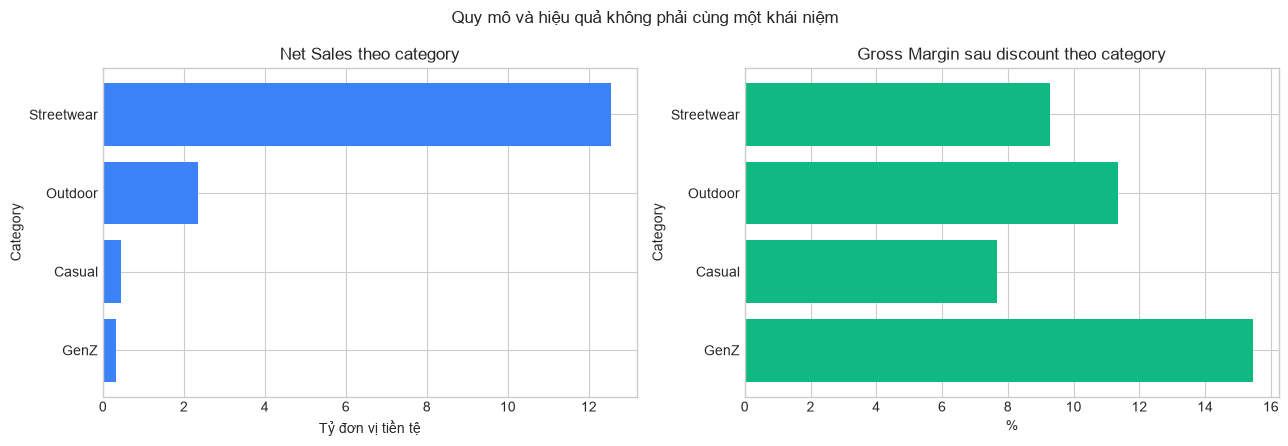

In [9]:
category_kpi = business_summary('category').sort_values('net_sales')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(category_kpi.category, category_kpi.net_sales / 1e9, color='#3B82F6')
axes[0].set(title='Net Sales theo category', xlabel='Tỷ đơn vị tiền tệ', ylabel='Category')
axes[1].barh(category_kpi.category, category_kpi.gross_margin_pct, color='#10B981')
axes[1].set(title='Gross Margin sau discount theo category', xlabel='%', ylabel='Category')
plt.suptitle('Quy mô và hiệu quả không phải cùng một khái niệm')
plt.tight_layout()
plt.show()

## 6. Thời gian và promotion

EDA theo thời gian giúp nhận ra seasonality và structural break. Tuy nhiên, một biến động xuất hiện cùng promotion chỉ cho thấy **association**, chưa đủ chứng minh promotion là nguyên nhân duy nhất.

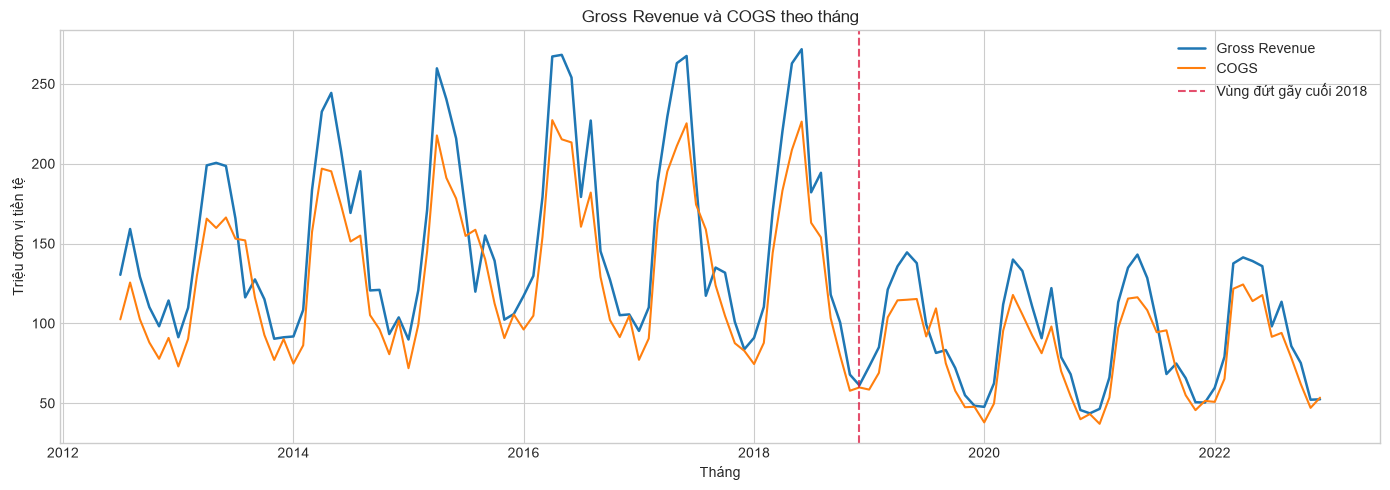

In [10]:
monthly = (daily_derived.set_index('order_date')[['Revenue', 'COGS']]
           .resample('MS').sum().reset_index())
monthly['gross_profit_before_discount'] = monthly.Revenue - monthly.COGS

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.order_date, monthly.Revenue / 1e6, label='Gross Revenue', linewidth=1.8)
ax.plot(monthly.order_date, monthly.COGS / 1e6, label='COGS', linewidth=1.5)
ax.axvline(pd.Timestamp('2018-12-01'), color='crimson', linestyle='--', alpha=.75,
           label='Vùng đứt gãy cuối 2018')
ax.set(title='Gross Revenue và COGS theo tháng', xlabel='Tháng', ylabel='Triệu đơn vị tiền tệ')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
promo_long = (items[['order_id', 'line_number', 'promo_id', 'promo_id_2']]
              .melt(id_vars=['order_id', 'line_number'], value_name='promo_code')
              .dropna(subset=['promo_code'])
              .drop(columns='variable')
              .rename(columns={'promo_code': 'promo_id'}))
dual_promo = items[items.promo_id_2.notna()].copy()
dual_promo['gross_revenue'] = dual_promo.quantity * dual_promo.unit_price
dual_promo['expected_discount'] = (dual_promo.gross_revenue * .10 + 50).round(2)

urban = promotions[promotions.promo_name.str.contains('Urban Blowout', case=False, na=False)]
august = daily_derived[daily_derived.order_date.dt.month.eq(8)].copy()
august['year'] = august.order_date.dt.year
august_year = august.groupby('year', as_index=False)[['Revenue', 'COGS']].sum()
august_year['cogs_revenue_ratio'] = august_year.COGS / august_year.Revenue

promo_evidence = pd.DataFrame({
    'Quan sát': ['Dòng có promo_id', 'Dòng có promo_id_2', 'Liên kết sau unpivot',
                 'Dòng hai promo khớp discount = 10% gross + 50'],
    'Giá trị': [items.promo_id.notna().sum(), items.promo_id_2.notna().sum(), len(promo_long),
                np.isclose(dual_promo.discount_amount, dual_promo.expected_discount, atol=.01).sum()]
})
show(promo_evidence, {'Giá trị': '{:,.0f}'})
print('Các chương trình Urban Blowout quan sát được:')
display(urban[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date',
               'applicable_category', 'stackable_flag']])
print('KPI tháng 8 theo năm:')
show(august_year, {'Revenue': '{:,.0f}', 'COGS': '{:,.0f}', 'cogs_revenue_ratio': '{:.3f}'})

,Quan sát,Giá trị
0,Dòng có promo_id,"276,316"
1,Dòng có promo_id_2,206
2,Liên kết sau unpivot,"276,522"
3,Dòng hai promo khớp discount = 10% gross + 50,206


Các chương trình Urban Blowout quan sát được:


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,stackable_flag
4,PROMO-0005,Urban Blowout 2013,fixed,50.00,2013-07-30,2013-09-02,Streetwear,0
14,PROMO-0015,Urban Blowout 2015,fixed,50.00,2015-07-30,2015-09-02,Streetwear,0
24,PROMO-0025,Urban Blowout 2017,fixed,50.00,2017-07-30,2017-09-02,Streetwear,0
34,PROMO-0035,Urban Blowout 2019,fixed,50.00,2019-07-30,2019-09-02,Streetwear,0
44,PROMO-0045,Urban Blowout 2021,fixed,50.00,2021-07-30,2021-09-02,Streetwear,0


KPI tháng 8 theo năm:


,year,Revenue,COGS,cogs_revenue_ratio
0,2012,"159,089,240","125,585,306",0.789
1,2013,"116,271,756","151,947,691",1.307
2,2014,"195,265,820","154,959,559",0.794
3,2015,"119,854,987","158,626,609",1.323
4,2016,"227,008,492","181,909,731",0.801
5,2017,"117,297,362","158,809,473",1.354
6,2018,"194,275,746","153,836,903",0.792
7,2019,"81,495,590","109,395,939",1.342
8,2020,"122,065,017","98,041,338",0.803
9,2021,"68,280,027","95,650,916",1.401


Điểm cần nói đúng:

- Hai cột promo là một **repeating group**; unpivot thành `order_item_promotion` cho ra 276.522 liên kết.
- 206 dòng có hai promotion được gán đồng thời. Không gọi cả hai là “stackable”: ở hai cặp quan sát, promotion chính có `stackable_flag=1`, promotion thứ hai có `stackable_flag=0`.
- Urban Blowout xuất hiện ở tháng 8 các năm lẻ và đi cùng giai đoạn Revenue thấp, COGS/Revenue cao. Đây là tín hiệu có giá trị cho planning/forecasting, nhưng từ observational data chưa thể kết luận causal effect thuần của promotion.

## 7. Thanh toán và giao hàng

`payment_method` trả lời cách thanh toán; `installments` là số kỳ; `payment_value` là net payment. `shipping_fee` ở nguồn không được cộng vào `payment_value` trong reconciliation, vì vậy không tự ý coi đó là doanh thu shipping đã thu từ khách.

In [12]:
payment_kpi = (payments.groupby('payment_method', as_index=False)
               .agg(orders=('order_id', 'count'), net_payment=('payment_value', 'sum'),
                    avg_installments=('installments', 'mean'))
               .sort_values('net_payment', ascending=False))

shipment_fact = shipments.copy()
shipment_fact['delivery_days'] = (shipment_fact.delivery_date - shipment_fact.ship_date).dt.days
shipment_summary = pd.DataFrame({'Giá trị': {
    'shipments': shipment_fact.order_id.count(),
    'avg_delivery_days': shipment_fact.delivery_days.mean(),
    'median_delivery_days': shipment_fact.delivery_days.median(),
    'avg_shipping_fee': shipment_fact.shipping_fee.mean(),
    'free_shipping_rate': shipment_fact.shipping_fee.eq(0).mean()
}})

show(payment_kpi, {'orders': '{:,.0f}', 'net_payment': '{:,.0f}', 'avg_installments': '{:.2f}'})
show(shipment_summary, {'Giá trị': '{:,.3f}'})
print(f'Đơn không có shipment: {orders.order_id.nunique() - shipments.order_id.nunique():,}')

,payment_method,orders,net_payment,avg_installments
3,credit_card,"356,352","8,630,069,413",3.88
4,paypal,"97,018","2,363,680,138",3.88
2,cod,"96,681","2,346,947,593",1.00
0,apple_pay,"64,763","1,564,269,610",3.88
1,bank_transfer,"32,131","775,902,511",3.85


,Giá trị
shipments,"566,067.000"
avg_delivery_days,4.499
median_delivery_days,4.000
avg_shipping_fee,4.963
free_shipping_rate,0.001


Đơn không có shipment: 80,878


## 8. Returns và reviews — hậu mãi ở grain dòng hàng

Nguồn con chỉ có `(order_id, product_id)` nhưng cặp đó không luôn định danh duy nhất một dòng hàng. Do đó notebook tái dựng:

1. `line_number` theo thứ tự xuất hiện trong từng `order_id`;
2. `occurrence_number` theo thứ tự xuất hiện trong từng `(order_id, product_id)`;
3. ghép return/review với occurrence tương ứng.

Đây là **quy tắc quyết định, tái lập được**, không phải ground truth do nguồn cung cấp.

In [13]:
item_key = items[['order_id', 'product_id', 'line_number', 'quantity']].copy()
item_key['occurrence_number'] = item_key.groupby(['order_id', 'product_id'], sort=False).cumcount() + 1
duplicate_pairs = (item_key.groupby(['order_id', 'product_id']).size().rename('item_rows')
                   .loc[lambda s: s.gt(1)].reset_index())

def map_child_to_line(child):
    mapped = child.copy()
    mapped['occurrence_number'] = mapped.groupby(['order_id', 'product_id'], sort=False).cumcount() + 1
    return mapped.merge(item_key, on=['order_id', 'product_id', 'occurrence_number'],
                        how='left', validate='one_to_one')

return_map = map_child_to_line(returns)
review_map = map_child_to_line(reviews)
ambiguous_returns = returns.merge(duplicate_pairs[['order_id', 'product_id']],
                                  on=['order_id', 'product_id'], how='inner')
ambiguous_reviews = reviews.merge(duplicate_pairs[['order_id', 'product_id']],
                                  on=['order_id', 'product_id'], how='inner')

mapping_evidence = pd.DataFrame({
    'Kiểm tra': ['Cặp (order_id, product_id) bị trùng trong order_items',
                 'Return nằm trên cặp nhập nhằng', 'Review nằm trên cặp nhập nhằng',
                 'Return mất line_number sau mapping', 'Review mất line_number sau mapping',
                 'Return quantity vượt quantity bán sau mapping'],
    'Giá trị': [len(duplicate_pairs), len(ambiguous_returns), len(ambiguous_reviews),
                return_map.line_number.isna().sum(), review_map.line_number.isna().sum(),
                return_map.return_quantity.gt(return_map.quantity).sum()]
})
show(mapping_evidence, {'Giá trị': '{:,.0f}'})

,Kiểm tra,Giá trị
0,"Cặp (order_id, product_id) bị trùng trong orde...",16
1,Return nằm trên cặp nhập nhằng,4
2,Review nằm trên cặp nhập nhằng,2
3,Return mất line_number sau mapping,0
4,Review mất line_number sau mapping,0
5,Return quantity vượt quantity bán sau mapping,0


In [14]:
return_fact = return_map.merge(
    item_fact[['order_id', 'line_number', 'category', 'segment', 'net_sales']],
    on=['order_id', 'line_number'], validate='one_to_one'
)
review_fact = review_map.merge(
    item_fact[['order_id', 'line_number', 'category', 'segment']],
    on=['order_id', 'line_number'], validate='one_to_one'
)

post_purchase_kpi = pd.DataFrame({
    'KPI': ['Return line rate', 'Return unit rate', 'Refund / Net Sales', 'Rating trung bình'],
    'Giá trị': [len(return_fact) / len(item_fact),
                return_fact.return_quantity.sum() / item_fact.quantity.sum(),
                return_fact.refund_amount.sum() / item_fact.net_sales.sum(),
                review_fact.rating.mean()]
})
show(post_purchase_kpi, {'Giá trị': '{:.4f}'})

return_by_category = (return_fact.groupby('category', as_index=False)
                      .agg(return_lines=('return_id', 'count'), returned_units=('return_quantity', 'sum'),
                           refunds=('refund_amount', 'sum')))
review_by_category = (review_fact.groupby('category', as_index=False)
                      .agg(reviews=('review_id', 'count'), avg_rating=('rating', 'mean')))
show(return_by_category.merge(review_by_category, on='category'), {
    'return_lines': '{:,.0f}', 'returned_units': '{:,.0f}', 'refunds': '{:,.0f}',
    'reviews': '{:,.0f}', 'avg_rating': '{:.3f}'
})

,KPI,Giá trị
0,Return line rate,0.0559
1,Return unit rate,0.0341
2,Refund / Net Sales,0.0326
3,Rating trung bình,3.9360


,category,return_lines,returned_units,refunds,reviews,avg_rating
0,Casual,"1,294","3,499","14,027,094","3,790",3.923
1,GenZ,"2,126","5,869","11,145,648","5,792",3.923
2,Outdoor,"14,720","40,417","78,717,515","41,265",3.934
3,Streetwear,"21,799","59,801","406,708,249","62,704",3.939


`orders.order_status='returned'` và bảng `returns` không nhất thiết đồng nghĩa tuyệt đối. Khi định nghĩa KPI chính thức cần chọn nguồn sự thật: trạng thái lifecycle của đơn hay event trả ở dòng hàng. Notebook dùng bảng `returns` cho return rate vì grain của câu hỏi là sản phẩm bị trả.

## 9. Inventory — snapshot vận hành, không phải giao dịch

`inventory.units_sold` là measure của hệ vận hành kho. Nguồn không chứng minh nó được tổng hợp từ `order_items`, nên không dùng cột này thay cho số lượng giao dịch. Giá trị của bảng là nhận diện stockout, overstock và tốc độ quay vòng tại từng snapshot.

In [15]:
inventory = data['inventory'].copy()
inventory['calc_stockout_flag'] = inventory.stockout_days.gt(0).astype(int)
inventory['calc_days_of_supply'] = (inventory.stock_on_hand / (inventory.units_sold / 30)).round(1)
inventory['calc_fill_rate'] = (1 - inventory.stockout_days / 30).round(4)
inventory['calc_sell_through_rate'] = (
    inventory.units_sold / (inventory.stock_on_hand + inventory.units_sold)
).round(4)
inventory['calc_overstock_flag'] = inventory.calc_days_of_supply.gt(90).astype(int)

inventory_formula_check = pd.DataFrame({
    'Cột nguồn': ['stockout_flag', 'days_of_supply', 'fill_rate', 'sell_through_rate', 'overstock_flag'],
    'Công thức khớp %': [
        inventory.stockout_flag.eq(inventory.calc_stockout_flag).mean() * 100,
        np.isclose(inventory.days_of_supply, inventory.calc_days_of_supply, atol=1e-9).mean() * 100,
        np.isclose(inventory.fill_rate, inventory.calc_fill_rate, atol=1e-9).mean() * 100,
        np.isclose(inventory.sell_through_rate, inventory.calc_sell_through_rate, atol=1e-9).mean() * 100,
        inventory.overstock_flag.eq(inventory.calc_overstock_flag).mean() * 100
    ]
})
show(inventory_formula_check, {'Công thức khớp %': '{:.1f}%'})

latest_inventory = inventory[inventory.snapshot_date.eq(inventory.snapshot_date.max())]
latest_inventory_kpi = (latest_inventory.groupby('category', as_index=False)
                        .agg(products=('product_id', 'nunique'), stock_on_hand=('stock_on_hand', 'sum'),
                             units_sold=('units_sold', 'sum'), stockout_rate=('stockout_flag', 'mean'),
                             overstock_rate=('overstock_flag', 'mean'),
                             avg_days_of_supply=('days_of_supply', 'mean')))
print(f'Snapshot mới nhất: {inventory.snapshot_date.max().date()}')
show(latest_inventory_kpi, {
    'products': '{:,.0f}', 'stock_on_hand': '{:,.0f}', 'units_sold': '{:,.0f}',
    'stockout_rate': '{:.1%}', 'overstock_rate': '{:.1%}', 'avg_days_of_supply': '{:.1f}'
})

,Cột nguồn,Công thức khớp %
0,stockout_flag,100.0%
1,days_of_supply,100.0%
2,fill_rate,100.0%
3,sell_through_rate,100.0%
4,overstock_flag,100.0%


Snapshot mới nhất: 2022-12-31


,category,products,stock_on_hand,units_sold,stockout_rate,overstock_rate,avg_days_of_supply
0,Casual,40,"4,095",190,77.5%,72.5%,831.0
1,GenZ,44,"5,126",199,56.8%,84.1%,1019.4
2,Outdoor,144,"49,929","1,797",66.0%,78.5%,2196.0
3,Streetwear,196,"45,085","1,379",68.4%,82.7%,2031.8


## 10. Web traffic so với sales

Ta có thể ghép hai chuỗi ở cùng ngày để khám phá tương quan. **Correlation không phải causation**; càng không phải quan hệ khách/session/order. Chỉ số `orders / sessions` dưới đây là proxy ở mức ngày, không nên gọi là conversion rate chính thức.

,Chỉ số,Giá trị
0,Số ngày ghép được,"3,652.0000"
1,"corr(sessions, Gross Revenue)",0.3211
2,"corr(unique_visitors, Gross Revenue)",0.3188
3,orders/sessions proxy trung bình,0.0074


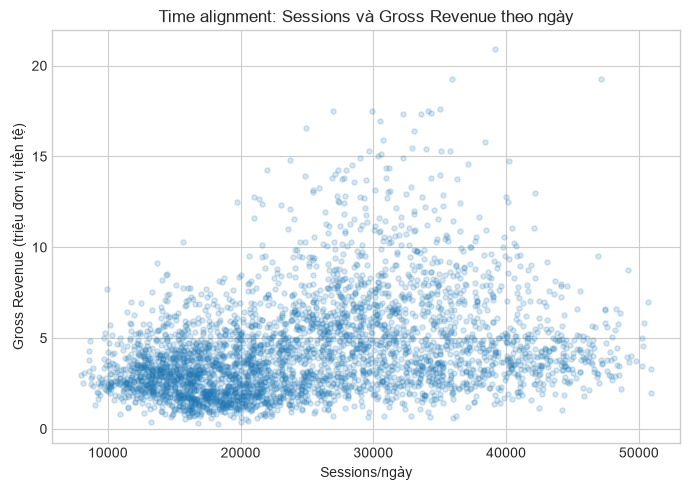

In [16]:
daily_orders = orders.groupby('order_date', as_index=False).agg(orders=('order_id', 'nunique'))
traffic_sales = (data['web_traffic']
                 .merge(daily_derived, left_on='date', right_on='order_date', validate='one_to_one')
                 .merge(daily_orders, on='order_date', validate='one_to_one'))
traffic_sales['orders_per_session_proxy'] = traffic_sales.orders / traffic_sales.sessions

traffic_summary = pd.DataFrame({
    'Chỉ số': ['Số ngày ghép được', 'corr(sessions, Gross Revenue)',
               'corr(unique_visitors, Gross Revenue)', 'orders/sessions proxy trung bình'],
    'Giá trị': [len(traffic_sales),
                traffic_sales.sessions.corr(traffic_sales.Revenue),
                traffic_sales.unique_visitors.corr(traffic_sales.Revenue),
                traffic_sales.orders_per_session_proxy.mean()]
})
show(traffic_summary, {'Giá trị': '{:,.4f}'})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(traffic_sales.sessions, traffic_sales.Revenue / 1e6, alpha=.18, s=14)
ax.set(title='Time alignment: Sessions và Gross Revenue theo ngày',
       xlabel='Sessions/ngày', ylabel='Gross Revenue (triệu đơn vị tiền tệ)')
plt.tight_layout()
plt.show()

## 11. Từ EDA đến thiết kế dữ liệu

### 11.1 Các khái niệm cần hiểu

- **Primary Key (PK)**: định danh duy nhất một dòng ở đúng grain.
- **Foreign Key (FK)**: buộc giá trị con phải tồn tại ở bảng cha; ngăn orphan.
- **Functional Dependency (FD)**: $X \rightarrow Y$ nghĩa là một giá trị $X$ luôn xác định đúng một $Y$.
- **Redundancy**: cùng một sự thật được lưu ở nhiều chỗ.
- **Update anomaly**: sửa một bản sao nhưng quên sửa bản khác, làm dữ liệu mâu thuẫn.
- **Junction table**: bảng nối biểu diễn quan hệ nhiều-nhiều.
- **View**: truy vấn được đặt tên; tính lại từ nguồn thay vì lưu thêm bản sao.

Ba mức chuẩn hóa có thể nhớ bằng câu:

> Mỗi thuộc tính không khóa phải phụ thuộc vào **khóa, toàn bộ khóa, và không gì ngoài khóa**.

| Chuẩn | Câu hỏi kiểm tra | Quyết định trong dataset |
|---|---|---|
| 1NF | Mỗi ô có nguyên tử, không có nhóm cột lặp, dòng có định danh? | thêm `line_number`; unpivot `promo_id/promo_id_2` |
| 2NF | Thuộc tính có phụ thuộc chỉ một phần khóa tổ hợp? | inventory tách thuộc tính product và year/month |
| 3NF | Thuộc tính không khóa có xác định thuộc tính không khóa khác? | tách `product_model`, geography, `review_title_label`; bỏ cột sao chép |

Việc bỏ một cột tính được như `days_of_supply` là kiểm soát **dư thừa dẫn xuất**, không tự động đồng nghĩa với 3NF. Hai nguyên tắc có liên quan nhưng không phải một.

### 11.2 Bằng chứng EDA cho từng quyết định chuẩn hóa

Các phép kiểm dưới đây chỉ chứng minh FD trên snapshot hiện có. Để bảo đảm dữ liệu tương lai, database còn cần PK/FK/UNIQUE/CHECK và ETL reconciliation.

In [17]:
def fd_violations(df, determinant, dependent):
    bad = df.groupby(determinant, dropna=False)[dependent].nunique(dropna=False) > 1
    return int(bad.any(axis=1).sum()) if isinstance(bad, pd.DataFrame) else int(bad.sum())

customer_city = customers.merge(geography[['zip', 'city']], on='zip', suffixes=('_customer', '_geo'))
order_customer = orders.merge(customers[['customer_id', 'zip']], on='customer_id',
                              suffixes=('_order', '_customer'))
payment_order = payments.merge(orders[['order_id', 'payment_method']], on='order_id',
                               suffixes=('_payment', '_order'))
review_order = reviews.merge(orders[['order_id', 'customer_id']], on='order_id',
                             suffixes=('_review', '_order'))

design_evidence = pd.DataFrame([
    ('1NF', '`(order_id, product_id)` không unique', len(duplicate_pairs), 'sinh `line_number`'),
    ('1NF', '`promo_id_2` có dữ liệu', int(items.promo_id_2.notna().sum()), 'tạo junction table'),
    ('2NF', '`product_id → product_name/category/segment` trong inventory',
     fd_violations(inventory, 'product_id', ['product_name', 'category', 'segment']), '0 vi phạm FD'),
    ('2NF', '`snapshot_date → year/month` trong inventory',
     fd_violations(inventory, 'snapshot_date', ['year', 'month']), '0 vi phạm FD'),
    ('3NF', '`product_name → category/segment`',
     fd_violations(products, 'product_name', ['category', 'segment']), 'tách product_model'),
    ('3NF', '`review_title → rating`',
     fd_violations(reviews, 'review_title', 'rating'), 'tách review_title_label'),
    ('Dư thừa sao chép', '`customers.city` khớp geography',
     int(customer_city.city_customer.ne(customer_city.city_geo).sum()), 'bỏ customers.city'),
    ('Dư thừa sao chép', '`orders.zip` khớp customers.zip',
     int(order_customer.zip_order.ne(order_customer.zip_customer).sum()), 'bỏ orders.zip'),
    ('Dư thừa sao chép', '`payments.payment_method` khớp orders',
     int(payment_order.payment_method_payment.ne(payment_order.payment_method_order).sum()),
     'chỉ giữ ở order'),
    ('Dư thừa sao chép', '`reviews.customer_id` khớp orders',
     int(review_order.customer_id_review.ne(review_order.customer_id_order).sum()),
     'suy qua order'),
    ('Dư thừa dẫn xuất', '5 cột inventory tái tính được',
     int((inventory_formula_check['Công thức khớp %'] < 100).sum()), 'bỏ 5 cột, tính khi đọc'),
    ('Dư thừa tổng hợp', '`sales.csv` tái tạo từ giao dịch',
     int(((daily_compare.Revenue_source-daily_compare.Revenue_derived).abs() > .01).sum()
         + ((daily_compare.COGS_source-daily_compare.COGS_derived).abs() > .01).sum()),
     'daily_sales là view')
], columns=['Lớp', 'Bằng chứng', 'Số vi phạm / trường hợp', 'Quyết định'])
show(design_evidence, {'Số vi phạm / trường hợp': '{:,.0f}'})

,Lớp,Bằng chứng,Số vi phạm / trường hợp,Quyết định
0,1NF,"`(order_id, product_id)` không unique",16,sinh `line_number`
1,1NF,`promo_id_2` có dữ liệu,206,tạo junction table
2,2NF,`product_id → product_name/category/segment` t...,0,0 vi phạm FD
3,2NF,`snapshot_date → year/month` trong inventory,0,0 vi phạm FD
4,3NF,`product_name → category/segment`,0,tách product_model
5,3NF,`review_title → rating`,0,tách review_title_label
6,Dư thừa sao chép,`customers.city` khớp geography,0,bỏ customers.city
7,Dư thừa sao chép,`orders.zip` khớp customers.zip,0,bỏ orders.zip
8,Dư thừa sao chép,`payments.payment_method` khớp orders,0,chỉ giữ ở order
9,Dư thừa sao chép,`reviews.customer_id` khớp orders,0,suy qua order


### 11.3 Mô hình 3NF được trình bày như thế nào?

Từ xương sống business, mô hình nguồn sự thật được tách thành 19 bảng:

| Miền | Bảng 3NF | Grain/khóa chính |
|---|---|---|
| Geography | `region`, `city`, `district`, `zip_area` | danh mục vùng/thành phố/quận/zip |
| Customer | `customer` | `customer_id` |
| Product | `product_model`, `product` | `product_name`; `product_id` |
| Promotion | `promotion`, `order_item_promotion` | `promo_id`; `(order_id, line_number, promo_id)` |
| Transaction | `order`, `order_item`, `payment`, `shipment` | `order_id`; `(order_id, line_number)` |
| Post-purchase | `product_return`, `review_title_label`, `review` | `return_id`; `review_title`; `review_id` |
| Operations | `inventory_snapshot`, `web_traffic` | `(snapshot_date, product_id)`; `traffic_date` |
| Forecast output | `daily_sales_forecast` | `forecast_date` — forecast, không phải actual |

`sales.csv` trở thành view `daily_sales`, nên không phải bảng cơ sở thứ 20.

### 11.4 Điều gì thực sự bảo đảm 3NF và không dư thừa?

1. **Xác định grain và khóa đúng**: `order_item` dùng `(order_id, line_number)`, không dùng cặp trùng `(order_id, product_id)`.
2. **Kiểm FD bằng EDA**: phát hiện `product_name → category, segment`, `review_title → rating` và các cột sao chép.
3. **Mỗi sự thật có một owner**: city thuộc geography, payment method thuộc order, rating label thuộc bảng tra cứu.
4. **Không lưu nhóm lặp**: promotion đi qua junction table.
5. **Không lưu lại dữ liệu tính được khi không cần**: `daily_sales` là view; inventory metrics tính khi đọc.
6. **Constraint ở database**: PK ngăn trùng, FK ngăn orphan, UNIQUE đỡ cardinality 1:1, CHECK giữ domain hợp lệ.
7. **ETL reconciliation**: đối chiếu cột trước khi loại; kiểm row count, fan-out và công thức sau load.

3NF **không** có nghĩa “không còn một byte nào lặp”, không bảo đảm dữ liệu đúng về mặt business, và không tự động tối ưu truy vấn phân tích. Với workload đọc nhiều, star schema có thể cố ý denormalize để giảm join.

### Judgment call ở geography

Tách `region/city/district/zip_area` đạt 3NF sách vở, nhưng `region` có thể tới từ zip theo hai đường (`zip → city → region` và `zip → district → region`). Production cần constraint/ETL ép hai đường nhất quán, hoặc chấp nhận một bảng geography phẳng làm single source. Đây là ví dụ cho thấy 3NF là công cụ, không phải mục tiêu tự thân.

## 12. Dataset có thể mang lại value gì?

| Value | Câu hỏi có thể trả lời | Bảng/KPI dùng | Giới hạn cần nói |
|---|---|---|---|
| Profitability | category/segment nào tạo Net Sales và Gross Margin tốt? | order items + product + COGS | chưa trừ refund, shipping, OPEX |
| Promotion | chương trình nào đi cùng volume/profit thay đổi? | promotion + line metrics | association, cần thiết kế causal để kết luận uplift |
| Customer/market | vùng và acquisition channel nào tạo nhiều đơn/value? | customer + geography + order | acquisition channel không phải order attribution |
| Fulfillment | lead time, shipping fee, đơn chưa shipment? | shipment + order | không có carrier/SLA chi tiết |
| Product quality | category nào có return/rating đáng chú ý? | return + review + item | sáu ánh xạ dòng hàng là tái dựng quyết định |
| Inventory | stockout/overstock và days of supply theo SKU/category? | inventory snapshot | units_sold không đối soát với giao dịch |
| Digital demand | traffic cùng biến động với sales ra sao? | web traffic + daily sales | không có session/order FK, không phải conversion thật |
| Planning/forecasting | seasonality, structural break, odd-year August | daily sales + promotion history | dữ liệu phụ trợ dừng ở 2022-12-31 |
| Data governance | đâu là source of truth, cột nào dư thừa? | toàn bộ schema + reconciliation | FD quan sát phải được constraint hóa cho dữ liệu mới |

Value lớn nhất của dataset không chỉ là dự báo hai cột. Nó cho phép nối **doanh thu → giá vốn → promotion → khách hàng → fulfillment → hậu mãi → tồn kho**, từ đó thảo luận cả tăng trưởng lẫn hiệu quả vận hành.

## 13. Kết luận để trình bày

1. Dataset mô tả một chuỗi bán lẻ end-to-end; xương sống là `CUSTOMER → ORDER → ORDER_ITEM ← PRODUCT`.
2. Gross Revenue, Net Payment và COGS là ba khái niệm khác nhau; nhầm chúng sẽ làm sai cả KPI lẫn thiết kế.
3. EDA không chỉ tìm trend mà còn kiểm grain, khóa, FD, công thức và fan-out trước khi mô hình hóa.
4. Thiết kế 3NF đưa mỗi sự thật về một nơi, dùng khóa/constraint để bảo vệ và dùng view cho tổng hợp dẫn xuất.
5. Sáu dòng return/review nhập nhằng được ánh xạ theo quy tắc tái lập được, nhưng phải công bố là giả định tái dựng.
6. Các phân tích promotion/traffic có giá trị định hướng, nhưng observational data không đủ để khẳng định causal impact.
7. Khi chuyển sang production, cần ETL + constraints + audit; notebook hiện là bằng chứng EDA và data contract, không phải database đang chạy.

Tài liệu chi tiết đi kèm trong repo: `docs/business_data_notes.md`, `docs/normalized_schema.md`, `normalized_schema.drawio`, `normalized_schema.mmd`, `docs/defense_notes.md` và `docs/thac_mac_dataset.md`.